# Linear Causal Disentanglement via ICA across Environments

We recover a latent linear SCM and its mixing matrix from multi-environment data,
using ICA in place of the precision-matrix decomposition of Squires et al. (2023).

**Model.** In environment $k$, latents follow $Z = A_kZ + \Omega_k^{1/2}\varepsilon$ with
$\mathrm{Cov}(\varepsilon)=I$, and observations are $X = GZ$ with $G\in\mathbb{R}^{p\times d}$
of full column rank. Writing $B_k = \Omega_k^{-1/2}(I-A_k)$ gives $X = GB_k^{-1}\varepsilon$:
each environment is a linear ICA problem with unmixing matrix $U_k = B_kG^{-1}$.

**Why ICA rather than covariance.** Second moments give $\Theta_k = U_k^\top U_k$, which
determines $U_k$ only up to an orthogonal factor; recovering that factor is what the RQ
machinery of Squires et al. is for. Non-Gaussianity determines $U_k$ up to a signed
permutation, which is a far smaller ambiguity, and makes the rank tests unnecessary.

**Two structural facts.**

1. Assumption 1(b), $B_k = B_0 + e_{i_k}c_k^\top$, implies $U_k - U_0$ has exactly one
   non-zero row: row $i_k$.
2. Assumption 2 (perfect interventions) sets $c_k = \lambda_ke_{i_k} - B_0^\top e_{i_k}$,
   so $(B_k)_{i_k,:} = \lambda_k e_{i_k}^\top$ and therefore
   $(U_k)_{i_k,:} = \lambda_k (G^{-1})_{i_k,:}$.

Fact 2 is the crux: **the intervened row of the unmixing matrix is, up to scale, the
corresponding row of $G^{-1}$.** Fact 1 tells us which row that is.

**Algorithm.** Run ICA per environment; align rows; for each row find the environment
where it is the odd one out (that is its intervention target, and the environment left
unassigned is observational); read $(G^{-1})_{i,:}$ off that row; invert to get $G$;
then $B_k = U_kG$ and $A_0 = I - \mathrm{diag}(B_0)^{-1}B_0$.

**Root-node caveat.** For a root $i$, $(B_0)_{i,:}\propto e_i^\top$ already, so an
intervention changes the row's magnitude but not its direction. We therefore fix the ICA
scale by requiring unit-variance sources and compare full rows, not just directions.

In [13]:
# =====================================================================
#  0. IMPORTS, SEED, STYLE
# =====================================================================
import os, random, itertools, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import FastICA

from wasserstein_ica import WassersteinICA

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
PALETTE = {"FastICA": "#0173B2", "OT-ICA": "#D55E00"}

PAPER_RC = {
    "figure.dpi": 120, "savefig.dpi": 400, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "axes.linewidth": 0.7, "lines.linewidth": 1.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linewidth": 0.5,
    "legend.frameon": False,
}
print(f"device = {DEV}   |   seed = {SEED}")

device = cpu   |   seed = 42


## 1. Data-generating process

Nodes are ordered so that an edge $j\to i$ implies $j>i$, making $A_0$ strictly upper
triangular. Environment $0$ is observational; environment $k\in\{1,\dots,d\}$ applies a
**perfect** intervention on node $\pi(k)$, zeroing row $\pi(k)$ of $A$ and resampling
$\Omega_{\pi(k)\pi(k)}$ from a disjoint range so that root interventions are detectable
by magnitude.

**Noise regimes.** Squires et al. use only second moments, so the law of $\varepsilon$ is
irrelevant to them. It is decisive for us. We consider:

| Regime | Description |
|---|---|
| `laplace` | all shocks Laplace; the regime where the `logcosh` proxy is well specified |
| `count_int` | Laplace baseline, intervened node's shock becomes Poisson$(\lambda)$ |
| `count_all` | all shocks Poisson with small rates |
| `leak` | as `count_int`, but the intervention also perturbs a neighbour's shock, violating the one-row-edit assumption |

`count_int` is the biologically motivated case: a knockout pushes the targeted gene into
the low-count regime while the rest of the system is unchanged. `leak` exists to
quantify what happens when the model assumption fails.

In [14]:
# =====================================================================
#  1. DGP   (make_G now enforces Assumption 1(c) at generation time)
# =====================================================================
def normalise_H(H):
    """Assumption 1(c): largest-|.| entry of each row set to 1."""
    Hn = H.copy()
    for i in range(Hn.shape[0]):
        j = int(np.argmax(np.abs(Hn[i])))
        Hn[i] = Hn[i] / Hn[i, j]
    return Hn


def make_G(p, d, seed, max_cond=50.0):
    """G whose pseudo-inverse already satisfies Assumption 1(c).

    Without this the recovered H differs from the true one by a diagonal
    Lambda, which survives the diag(B)^{-1}B normalisation and rescales every
    edge weight by Lambda_ii / Lambda_jj.
    """
    rng = np.random.default_rng(seed + 13)
    while True:
        G = rng.uniform(-2, 2, (p, d))
        if np.linalg.cond(G) < max_cond:
            return np.linalg.pinv(normalise_H(np.linalg.pinv(G)))


def make_scm(d, seed, density=0.75, w_lo=0.25, w_hi=1.0):
    rng = np.random.default_rng(seed)
    A0 = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            if rng.random() < density:
                A0[i, j] = rng.uniform(w_lo, w_hi) * rng.choice([-1.0, 1.0])
    Om0 = rng.uniform(2.0, 4.0, d)
    targets = rng.permutation(d)
    return A0, Om0, targets


def env_matrices(A0, Om0, targets, seed):
    rng = np.random.default_rng(seed + 7)
    d = A0.shape[0]
    Bs, tgt = [np.diag(Om0 ** -0.5) @ (np.eye(d) - A0)], [None]
    for i in targets:
        Ak, Omk = A0.copy(), Om0.copy()
        Ak[i, :] = 0.0
        Omk[i] = rng.uniform(6.0, 8.0)
        Bs.append(np.diag(Omk ** -0.5) @ (np.eye(d) - Ak))
        tgt.append(int(i))
    return Bs, tgt


def _std(x):
    return (x - x.mean()) / x.std()


def draw_eps(regime, d, n, rng, target=None, lam=0.5, leak_rho=0.6, pool=None):
    E = np.empty((d, n))
    for i in range(d):
        if regime == "laplace":
            E[i] = _std(rng.laplace(0, 1, n))
        elif regime == "count_all":
            E[i] = _std(rng.poisson(lam + 0.25 * (i % 3), n).astype(float))
        elif regime in ("count_int", "leak"):
            E[i] = (_std(rng.poisson(lam, n).astype(float)) if i == target
                    else _std(rng.laplace(0, 1, n)))
        elif regime == "pbmc":
            s = rng.choice(pool[i], n, replace=True).astype(float)
            if i == target:
                s = rng.binomial(s.astype(int), 0.25).astype(float)
            E[i] = _std(s)
        else:
            raise ValueError(regime)

    if regime == "leak" and target is not None and d > 1:
        nb = (target + 1) % d
        E[nb] = _std(np.sqrt(1 - leak_rho ** 2) * E[nb] + leak_rho * E[target])
    return E


def simulate(regime, d, p, n, seed, **kw):
    A0, Om0, order = make_scm(d, seed)
    Bs, tgt = env_matrices(A0, Om0, order, seed)
    G = make_G(p, d, seed)
    rng = np.random.default_rng(seed + 101)
    Xs = [G @ np.linalg.solve(B, draw_eps(regime, d, n, rng, target=tgt[k], **kw))
          for k, B in enumerate(Bs)]
    return Xs, Bs, tgt, G, A0

## 2. ICA solvers and the shared reduction

For $p>d$ the observations lie in the $d$-dimensional column space of $G$, identical
across environments. We therefore compute one **pooled** orthonormal basis $V\in\mathbb{R}^{p\times d}$
from all environments together and work in $\tilde X_k = V^\top X_k$. Writing
$\tilde G = V^\top G$ gives $\tilde U_k = B_k\tilde G^{-1}$, so the reduced problem has
exactly the structure derived above, and $H = G^\dagger = \tilde G^{-1}V^\top$.

Both solvers are required to return **unit-variance sources**, which removes the ICA
scale ambiguity and leaves only a signed permutation. This matters: root-node
interventions are visible only in the row magnitudes.

In [15]:
# =====================================================================
#  2. SOLVERS
# =====================================================================
def pooled_basis(Xs, d):
    """Common orthonormal basis for col(G), estimated from all environments."""
    Xc = np.concatenate([X - X.mean(1, keepdims=True) for X in Xs], axis=1)
    V, _, _ = np.linalg.svd(Xc, full_matrices=False)
    return V[:, :d]


def _unit_var(U, Xc):
    S = U @ Xc
    return U / S.std(1, keepdims=True)


def ot_ica(Xd, seed, n_restarts=16, defl_iter=200, sym_iter=400, lr=0.1, dither=0.05):
    """OT-ICA on reduced data (d, n). Returns U with unit-variance sources."""
    set_seed(seed)
    d = Xd.shape[0]
    Xc = Xd - Xd.mean(1, keepdims=True)
    m = WassersteinICA(torch.tensor(Xc, dtype=torch.float32, device=DEV))
    m.whiten()
    ws = []
    for _ in range(d):
        prev = torch.stack(ws) if ws else None
        w, _s = m.optimize_wasserstein2(prev_components=prev, continuous=True,
                                        max_iter=defl_iter, lr=0.1,
                                        n_restarts=n_restarts, dither_sigma=dither)
        ws.append(w)
    W = m.optimize_symmetric(n_components=d, optimizer="stiefel", init_w=torch.stack(ws),
                             use_sinkhorn=False, max_iter=sym_iter, lr=lr,
                             dither_sigma=dither, batch_size=1024)
    U = (W @ m.W_white).detach().cpu().numpy().astype(np.float64)
    return _unit_var(U, Xc)


def fast_ica(Xd, seed, max_iter=10000, tol=1e-5):
    Xc = Xd - Xd.mean(1, keepdims=True)
    ica = FastICA(n_components=Xd.shape[0], whiten="unit-variance", fun="logcosh",
                  max_iter=max_iter, tol=tol, random_state=seed)
    ica.fit(Xc.T)
    return _unit_var(ica.components_.astype(np.float64), Xc)


SOLVERS = {"OT-ICA": ot_ica, "FastICA": fast_ica}


def amari(W, A):
    P = np.abs(W @ A)
    n = P.shape[0]
    return (np.sum(np.sum(P / P.max(1, keepdims=True), 1) - 1) +
            np.sum(np.sum(P / P.max(0, keepdims=True), 0) - 1)) / (2 * n)

## 3. The disentanglement algorithm

Three steps, none of which involves a rank test.

**Alignment.** ICA returns rows in an arbitrary order per environment. Any two
environments agree on at least $d-2$ rows, so we align by Hungarian assignment on
$|\cos|$ between rows. To avoid an ambiguous pairing of the two mismatched rows we align
in two passes: first to an arbitrary anchor, then to a **row-wise medoid** across
environments. Since row $i$ equals $(B_0)_{i,:}$ in $d$ of the $d+1$ environments, the
medoid recovers $B_0$'s rows, after which every environment differs from the consensus
in at most one row and the assignment is unambiguous.

**Target and observational identification.** With rows aligned, let $\delta_{ik}$ be the
distance from row $i$ of $\hat U_k$ to the consensus. Assigning rows to environments so
as to maximise $\sum_i\delta_{i,k_i}$ (rectangular Hungarian) gives each node's
intervening environment; the one environment left unassigned is observational.

**Parameter recovery.** $\hat H_{i,:}\propto(\hat U_{k_i})_{i,:}$, rescaled by
Assumption 1(c) — largest-magnitude entry of each row set to $1$, leftmost positive on
ties. Then $\hat G=\hat H^\dagger$, $\hat B_k = \hat U_k\hat G$, and
$\hat A_0 = I - \mathrm{diag}(\hat B_0)^{-1}\hat B_0$, in which the unknown row scaling
of $\hat B_0$ cancels.

In [16]:
# =====================================================================
#  3. DISENTANGLEMENT
# =====================================================================
def _rownorm(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)


def align_to(ref, U, eps=1e-12):
    """Permute and sign-align rows of U to ref.

    The cost is -log(1 - |cos|) rather than |cos|: under Assumption 1(b) all but
    one row of U match ref exactly, and this transform makes those exact matches
    dominate the assignment, so the intervened row is placed by elimination.
    Maximising sum|cos| instead lets a pair of correlated rows outscore the
    correct permutation, which silently corrupts H.
    """
    C = _rownorm(ref) @ _rownorm(U).T
    A = np.abs(C)
    score = -np.log(np.clip(1.0 - A, eps, None))
    r, c = linear_sum_assignment(-score)
    s = np.sign(C[r, c]); s[s == 0] = 1.0
    return U[c] * s[:, None]


def consensus(Us):
    d = Us[0].shape[0]
    out = np.empty_like(Us[0])
    for i in range(d):
        V = np.stack([U[i] for U in Us])
        V = V * np.sign(V @ V[0])[:, None]
        D = np.linalg.norm(V[:, None, :] - V[None, :, :], axis=-1)
        out[i] = V[int(np.argmin(D.sum(1)))]
    return out


def from_unmixing(Us_raw, V, d):
    """Downstream algorithm, shared by the estimated and oracle paths."""
    Us = [align_to(Us_raw[0], U) for U in Us_raw]
    Cn = consensus(Us)
    Us = [align_to(Cn, U) for U in Us]
    Cn = consensus(Us)

    delta = np.stack([[np.linalg.norm(U[i] - Cn[i]) for U in Us] for i in range(d)])
    rows, envs = linear_sum_assignment(-delta)
    tgt_hat = {int(k): int(i) for i, k in zip(rows, envs)}
    obs_hat = int(next(k for k in range(len(Us)) if k not in tgt_hat))

    H_red = np.stack([Us[envs[i]][i] for i in range(d)])      # rows[i] == i here
    H_hat = normalise_H(H_red @ V.T)
    Gr_hat = np.linalg.inv(H_hat @ V)
    Bs_hat = [U @ Gr_hat for U in Us]

    B0 = Bs_hat[obs_hat]
    A_hat = np.eye(d) - B0 / np.diag(B0)[:, None]
    np.fill_diagonal(A_hat, 0.0)

    # rows changed per environment, relative to that environment's own scale
    scale = np.median(np.linalg.norm(Cn, axis=1))
    n_changed = [(delta[:, k] > 0.15 * scale).sum() for k in range(len(Us))]

    return dict(U=Us, H=H_hat, G=np.linalg.pinv(H_hat), A=A_hat, B=Bs_hat,
                targets=tgt_hat, obs=obs_hat, delta=delta,
                n_changed=n_changed, V=V, Gr=Gr_hat)


def disentangle(Xs, d, solver, seed):
    V = pooled_basis(Xs, d)
    Us_raw = [SOLVERS[solver](V.T @ X, seed + 17 * k) for k, X in enumerate(Xs)]
    return from_unmixing(Us_raw, V, d)


def disentangle_oracle(Xs, Bs, G, d):
    """Same pipeline fed the exact unmixing matrices. Must be near-exact."""
    V = pooled_basis(Xs, d)
    Gr = V.T @ G
    Us = [B @ np.linalg.inv(Gr) for B in Bs]
    return from_unmixing(Us, V, d)

## 4. Metrics

- **$\|\hat H - H\|_F$** — error in the demixing map, both normalised by Assumption 1(c).
  Directly comparable to Fig. 2(a) of Squires et al.
- **Target accuracy** — fraction of environments whose intervention target is correctly
  identified, plus whether the observational environment is correctly found.
- **Graph recovery** — precision, recall, F1 and SHD on $\mathrm{supp}(A_0)$ at threshold
  $0.1$ (true non-zero weights are $\geq0.25$ by construction).
- **Amari error** — quality of the ICA step itself, averaged over environments. This is
  the quantity that the rest of the pipeline inherits.
- **Rows changed per environment** — should be $1$ under Assumption 1(b); larger values
  indicate the one-row-edit assumption is violated.

Because each environment identifies one latent node, the intervention targets provide a
canonical labelling of the latents. No optimisation over $S(\mathcal{G})$ is needed.

In [17]:
# =====================================================================
#  4. METRICS  (resolve the latent relabelling before comparing)
# =====================================================================
def latent_perm(U_hat_obs, U_true_obs):
    """perm[i] = true latent index of aligned row i."""
    C = _rownorm(U_hat_obs) @ _rownorm(U_true_obs).T
    _, c = linear_sum_assignment(-np.abs(C))
    return c


def evaluate(res, Bs, tgt, G, A0, d):
    V = res["V"]
    U0_true = Bs[0] @ np.linalg.inv(V.T @ G)
    perm = latent_perm(res["U"][0], U0_true)       # env 0 is observational by construction

    H_true = normalise_H(np.linalg.pinv(G))
    H_rel = np.zeros_like(res["H"]); H_rel[perm] = res["H"]
    err_H = float(np.linalg.norm(H_rel - H_true))

    A_rel = np.zeros((d, d)); A_rel[np.ix_(perm, perm)] = res["A"]

    obs_ok = int(res["obs"] == 0)
    tgt_ok = np.mean([perm[res["targets"][k]] == tgt[k] if k in res["targets"] else False
                      for k in range(1, len(Bs))])

    P = (np.abs(A_rel) > 0.1).astype(int)
    T = (np.abs(A0) > 1e-9).astype(int)
    tp = int((P & T).sum()); fp = int((P & ~T).sum()); fn = int((~P & T).sum())
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    am = np.mean([amari(res["U"][k], (V.T @ G) @ np.linalg.inv(Bs[k]))
                  for k in range(len(Bs))])

    return dict(err_H=err_H, err_A=float(np.linalg.norm(A_rel - A0)),
                obs_ok=obs_ok, tgt_acc=float(tgt_ok),
                precision=prec, recall=rec, f1=f1, shd=fp + fn, amari=am,
                rows_changed=float(np.mean(res["n_changed"][1:])),
                obs_rows_changed=float(res["n_changed"][0]))


def run_once(regime, d, p, n, seed, solver, **kw):
    Xs, Bs, tgt, G, A0 = simulate(regime, d, p, n, seed, **kw)
    res = disentangle(Xs, d, solver, seed)
    m = evaluate(res, Bs, tgt, G, A0, d)
    m.update(regime=regime, d=d, n=n, seed=seed, method=solver)
    return m

In [18]:
# =====================================================================
#  ORACLE TEST: feed the pipeline exact unmixing matrices.
#  Anything other than near-exact recovery means the ALGORITHM is wrong,
#  not the ICA.
# =====================================================================
D, P, N = 4, 8, 20_000

print(f"{'seed':>5} {'err_H':>9} {'tgt':>6} {'obs':>5} {'F1':>6} {'rows/env':>9}")
for s in range(SEED, SEED + 5):
    Xs, Bs, tgt, G, A0 = simulate("laplace", D, P, N, s)
    res = disentangle_oracle(Xs, Bs, G, D)
    m = evaluate(res, Bs, tgt, G, A0, D)
    print(f"{s:>5} {m['err_H']:>9.2e} {m['tgt_acc']:>6.2f} {m['obs_ok']:>5d} "
          f"{m['f1']:>6.2f} {m['rows_changed']:>9.2f}")

# structure of delta: one large entry per column except the observational one
Xs, Bs, tgt, G, A0 = simulate("laplace", D, P, N, SEED)
res = disentangle_oracle(Xs, Bs, G, D)
print("\ndelta (rows = latents, cols = environments; col 0 is observational):")
print(np.round(res["delta"], 3))
print("true targets :", tgt[1:])
print("est. targets :", res["targets"], "  est. observational:", res["obs"])

 seed     err_H    tgt   obs     F1  rows/env


   42  8.15e-15   1.00     1   1.00      1.00
   43  4.72e-15   1.00     1   1.00      1.00
   44  5.63e-15   1.00     1   1.00      0.75
   45  1.23e-14   1.00     1   1.00      1.00
   46  6.86e-15   1.00     1   1.00      1.00

delta (rows = latents, cols = environments; col 0 is observational):
[[0.    0.    1.072 0.    0.   ]
 [0.    0.288 0.    0.    0.   ]
 [0.    0.    0.    0.565 0.   ]
 [0.    0.    0.    0.    0.408]]
true targets : [1, 0, 2, 3]
est. targets : {2: 0, 1: 1, 3: 2, 4: 3}   est. observational: 0


In [19]:
bad = []
for s in range(SEED, SEED + 20):
    Xs, Bs, tgt, G, A0 = simulate("laplace", 4, 8, 20_000, s)
    m = evaluate(disentangle_oracle(Xs, Bs, G, 4), Bs, tgt, G, A0, 4)
    if m["err_H"] > 1e-8:
        bad.append((s, m["err_H"], m["tgt_acc"], m["f1"]))
print("failures:", bad if bad else "none — oracle exact on all 20 seeds")

failures: none — oracle exact on all 20 seeds


In [20]:
# =====================================================================
#  WHY DOES THE ORACLE FAIL ON SEED 44?
# =====================================================================
Xs, Bs, tgt, G, A0 = simulate("laplace", 4, 8, 20_000, 44)
res = disentangle_oracle(Xs, Bs, G, 4)
H_true = normalise_H(np.linalg.pinv(G))

print("cond(G) =", f"{np.linalg.cond(G):.1f}", "  cond(H) =", f"{np.linalg.cond(H_true):.1f}")
print("per-row ||H_hat - H_true|| :", np.round(np.linalg.norm(res["H"] - H_true, axis=1), 4))
print("per-row |cos| with truth   :",
      np.round(np.abs(np.sum(_rownorm(res["H"]) * _rownorm(H_true), 1)), 6))
print("argmax column, H_hat  :", np.argmax(np.abs(res["H"]), 1))
print("argmax column, H_true :", np.argmax(np.abs(H_true), 1))
print("top-2 |entries| per row of H_true:")
print(np.round(np.sort(np.abs(H_true), 1)[:, -2:], 4))
print("roots (no parents):", [i for i in range(4) if not A0[i].any()])

cond(G) = 3.9   cond(H) = 3.9
per-row ||H_hat - H_true|| : [0. 0. 0. 0.]
per-row |cos| with truth   : [1. 1. 1. 1.]
argmax column, H_hat  : [0 1 2 1]
argmax column, H_true : [0 1 2 1]
top-2 |entries| per row of H_true:
[[0.8647 1.    ]
 [0.5086 1.    ]
 [0.9581 1.    ]
 [0.657  1.    ]]
roots (no parents): [3]


In [21]:
# =====================================================================
#  5. SMOKE TEST  (run this before the sweep)
# =====================================================================
D, P, N = 4, 8, 20_000
for reg in ["laplace", "count_int", "count_all"]:
    line = [f"{reg:<11s}"]
    for sol in ["OT-ICA", "FastICA"]:
        m = run_once(reg, D, P, N, SEED, sol)
        line.append(f"{sol} err_H {m['err_H']:6.3f}  tgt {m['tgt_acc']:.2f}  "
                    f"F1 {m['f1']:.2f}  Amari {m['amari']:.4f}")
    print("   |   ".join(line))

laplace       |   OT-ICA err_H  0.098  tgt 1.00  F1 1.00  Amari 0.0194   |   FastICA err_H  0.083  tgt 1.00  F1 1.00  Amari 0.0207
count_int     |   OT-ICA err_H  0.003  tgt 1.00  F1 1.00  Amari 0.0147   |   FastICA err_H  3.778  tgt 1.00  F1 1.00  Amari 0.0254
count_all     |   OT-ICA err_H  0.032  tgt 1.00  F1 1.00  Amari 0.0077   |   FastICA err_H  3.029  tgt 0.25  F1 0.31  Amari 0.8148


In [22]:
# =====================================================================
#  6. SWEEP OVER REGIMES AND SEEDS
# =====================================================================
import time

REGIMES = ["laplace", "count_int", "count_all", "leak"]
D, P, N, N_SEEDS = 4, 8, 20_000, 10
SEEDS = [SEED + i for i in range(N_SEEDS)]

rows, t0 = [], time.time()
for reg in REGIMES:
    for s in SEEDS:
        for sol in ["OT-ICA", "FastICA"]:
            rows.append(run_once(reg, D, P, N, s, sol))
    print(f"  {reg:<11s} done   {(time.time()-t0)/60:5.1f} min")

res = pd.DataFrame(rows)
res.to_csv("disentanglement_sweep.csv", index=False)

summ = (res.groupby(["regime", "method"])
           [["amari", "err_H", "tgt_acc", "f1", "shd", "rows_changed"]]
           .agg(["mean", "std"]).round(3))
print("\n=== mean (s.d.) over %d seeds, d=%d, p=%d, n=%d ===" % (N_SEEDS, D, P, N))
print(summ.to_string())

  laplace     done     3.3 min
  count_int   done     6.6 min
  count_all   done    10.4 min
  leak        done    14.0 min

=== mean (s.d.) over 10 seeds, d=4, p=8, n=20000 ===
                   amari         err_H        tgt_acc            f1         shd        rows_changed       
                    mean    std   mean    std    mean    std   mean    std mean    std         mean    std
regime    method                                                                                          
count_all FastICA  0.854  0.097  4.294  0.963   0.400  0.175  0.440  0.105  8.0  1.333        3.075  0.265
          OT-ICA   0.008  0.001  0.039  0.014   1.000  0.000  1.000  0.000  0.0  0.000        0.975  0.079
count_int FastICA  0.024  0.003  0.872  1.557   1.000  0.000  1.000  0.000  0.0  0.000        0.975  0.079
          OT-ICA   0.014  0.002  0.003  0.001   1.000  0.000  1.000  0.000  0.0  0.000        0.975  0.079
laplace   FastICA  0.019  0.002  0.081  0.016   1.000  0.000  1.000  0.00

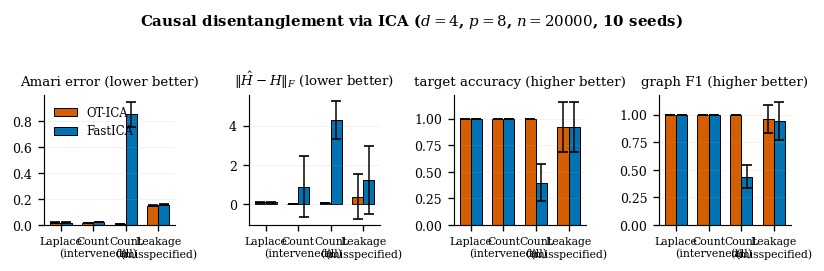

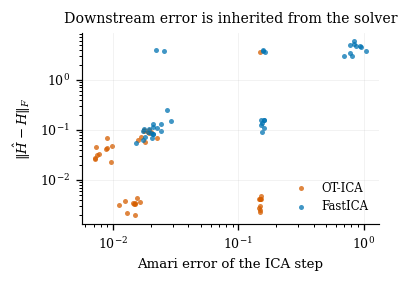

In [23]:
# =====================================================================
#  7. FIGURE: ICA quality propagates to structure recovery
# =====================================================================
LAB = {"laplace": "Laplace", "count_int": "Count\n(intervened)",
       "count_all": "Count\n(all)", "leak": "Leakage\n(misspecified)"}

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 4, figsize=(6.9, 2.1))
    panels = [("amari", "Amari error", "lower"), ("err_H", r"$\|\hat H - H\|_F$", "lower"),
              ("tgt_acc", "target accuracy", "higher"), ("f1", "graph F1", "higher")]
    w, xs = 0.34, np.arange(len(REGIMES))
    for ax, (key, lab, dirn) in zip(axes, panels):
        for off, tag in zip([-w/2, w/2], ["OT-ICA", "FastICA"]):
            g = res[res.method == tag].groupby("regime")[key]
            mu = [g.mean()[r] for r in REGIMES]; sd = [g.std()[r] for r in REGIMES]
            ax.bar(xs + off, mu, w, yerr=sd, color=PALETTE[tag], edgecolor="black",
                   lw=0.6, capsize=3, error_kw=dict(lw=0.9), label=tag)
        ax.set_xticks(xs); ax.set_xticklabels([LAB[r] for r in REGIMES], fontsize=6.5)
        ax.set_title(f"{lab} ({dirn} better)", fontsize=8)
        ax.grid(axis="x", visible=False)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Causal disentanglement via ICA ($d={D}$, $p={P}$, $n={N}$, "
                 f"{N_SEEDS} seeds)", fontweight="bold", fontsize=9, y=1.04)
    fig.tight_layout(w_pad=1.6)
    fig.savefig("disentanglement_regimes.pdf")
    plt.show()

# scatter: ICA quality -> downstream error
with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(3.3, 2.4))
    for tag in ["OT-ICA", "FastICA"]:
        sub = res[res.method == tag]
        ax.scatter(sub.amari, sub.err_H, s=9, color=PALETTE[tag], alpha=0.75,
                   lw=0, label=tag)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Amari error of the ICA step")
    ax.set_ylabel(r"$\|\hat H - H\|_F$")
    ax.set_title("Downstream error is inherited from the solver", fontsize=8.5)
    ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig("disentanglement_propagation.pdf"); plt.show()

## 8. Semi-synthetic: PBMC 3k count marginals

The exogenous shocks are drawn from the empirical UMI-count distributions of real genes,
resampled independently per gene so that $\varepsilon$ is exactly independent while
retaining real count marginals. Genes are chosen for low mean count (the regime where
count structure is pronounced) and low pairwise correlation.

An intervention is modelled as **binomial thinning** of the targeted gene's counts, which
is the standard model for reduced expression and keeps the shock count-valued. The DAG,
$G$ and the intervention targets are known by construction, so the ground truth is exact;
only the shock marginals are real. This mirrors the semi-synthetic protocol of Squires
et al., who fit parameters on real data and then re-simulate.

In [24]:
# =====================================================================
#  8. PBMC 3k SEMI-SYNTHETIC
# =====================================================================
def load_pbmc_pool(d, seed=SEED, mean_lo=0.15, mean_hi=1.2, max_corr=0.05, n_cand=400):
    """Empirical count vectors for d low-count, weakly correlated genes."""
    try:
        import scanpy as sc
        ad = sc.datasets.pbmc3k()
        Xc = ad.X.toarray() if hasattr(ad.X, "toarray") else np.asarray(ad.X)
        names = np.asarray(ad.var_names)
        print(f"PBMC 3k: {Xc.shape[0]} cells x {Xc.shape[1]} genes")
    except Exception as e:
        print(f"scanpy unavailable ({e}); falling back to synthetic Poisson counts")
        rng = np.random.default_rng(seed)
        Xc = rng.poisson(0.5, (2700, 500)).astype(float)
        names = np.array([f"sim{i}" for i in range(500)])

    mu = Xc.mean(0)
    keep = np.where((mu > mean_lo) & (mu < mean_hi))[0]
    keep = keep[np.random.default_rng(seed).permutation(len(keep))][:n_cand]   # was: sort by -std

    chosen = [int(keep[0])]
    for g in keep[1:]:
        C = np.corrcoef(np.vstack([Xc[:, chosen].T, Xc[:, g]]))[-1, :-1]
        if np.all(np.abs(C) < max_corr):
            chosen.append(int(g))
        if len(chosen) == d:
            break
    if len(chosen) < d:
        raise RuntimeError("relax max_corr or widen the mean-count window")

    names_sel = list(names[chosen])
    print("genes:", names_sel, " mean counts:", np.round(mu[chosen], 2))
    return [Xc[:, g].astype(float) for g in chosen], names_sel


POOL, GENE_NAMES = load_pbmc_pool(D)

pb_rows = []
for s in SEEDS:
    for sol in ["OT-ICA", "FastICA"]:
        pb_rows.append(run_once("pbmc", D, P, N, s, sol, pool=POOL))
pb = pd.DataFrame(pb_rows)

print("\n=== PBMC 3k semi-synthetic, mean (s.d.) over %d seeds ===" % N_SEEDS)
print(pb.groupby("method")[["amari", "err_H", "tgt_acc", "f1", "shd", "rows_changed"]]
        .agg(["mean", "std"]).round(3).to_string())

# ---------------------------- LaTeX ----------------------------
print("\n" + r"\begin{tabular}{lccccc}")
print(r"\toprule")
print(r"Method & Amari $\downarrow$ & $\|\hat H-H\|_F$ $\downarrow$ "
      r"& target acc.\ $\uparrow$ & F1 $\uparrow$ & SHD $\downarrow$ \\")
print(r"\midrule")
for tag in ["OT-ICA", "FastICA"]:
    g = pb[pb.method == tag]
    print(f"{tag} & {g.amari.mean():.4f}\\,({g.amari.std():.4f}) "
          f"& {g.err_H.mean():.3f}\\,({g.err_H.std():.3f}) "
          f"& {g.tgt_acc.mean():.2f} & {g.f1.mean():.2f}\\,({g.f1.std():.2f}) "
          f"& {g.shd.mean():.1f} \\\\")
print(r"\bottomrule" + "\n" + r"\end{tabular}")

PBMC 3k: 2700 cells x 32738 genes
genes: ['BLVRB', 'COX6C', 'TMEM59', 'ILF3-AS1']  mean counts: [0.24 0.68 0.56 0.21]

=== PBMC 3k semi-synthetic, mean (s.d.) over 10 seeds ===
         amari         err_H        tgt_acc        f1       shd      rows_changed       
          mean    std   mean    std    mean  std mean  std mean  std         mean    std
method                                                                                  
FastICA  0.012  0.002  0.049  0.017     1.0  0.0  1.0  0.0  0.0  0.0        0.975  0.079
OT-ICA   0.009  0.002  0.036  0.016     1.0  0.0  1.0  0.0  0.0  0.0        0.975  0.079

\begin{tabular}{lccccc}
\toprule
Method & Amari $\downarrow$ & $\|\hat H-H\|_F$ $\downarrow$ & target acc.\ $\uparrow$ & F1 $\uparrow$ & SHD $\downarrow$ \\
\midrule
OT-ICA & 0.0085\,(0.0017) & 0.036\,(0.016) & 1.00 & 1.00\,(0.00) & 0.0 \\
FastICA & 0.0118\,(0.0016) & 0.049\,(0.017) & 1.00 & 1.00\,(0.00) & 0.0 \\
\bottomrule
\end{tabular}


In [27]:
# =====================================================================
#  CONTRAST HELPERS (self-contained; mirrors the discrete-analysis notebook)
# =====================================================================
import scipy.stats

def analytical_target(n):
    """Exact per-bin Gaussian mean, matching WassersteinICA."""
    p = np.linspace(0.0, 1.0, n + 1)
    z = scipy.stats.norm.ppf(p)
    phi = scipy.stats.norm.pdf(z)
    phi[0] = phi[-1] = 0.0
    return n * (phi[:-1] - phi[1:])

_zq, _wq = np.polynomial.hermite_e.hermegauss(200)
C_GAUSS = float(np.sum(_wq * np.log(np.cosh(_zq))) / np.sqrt(2 * np.pi))

def w2_sq(y, target):
    return float(np.mean((np.sort(_std(y)) - target) ** 2))

def logcosh_sq(y):
    return float((np.mean(np.log(np.cosh(_std(y)))) - C_GAUSS) ** 2)

print(f"E[log cosh N(0,1)] = {C_GAUSS:.6f}")

E[log cosh N(0,1)] = 0.374567


In [28]:
# =====================================================================
#  CONTRAST DETECTABILITY OF THE SELECTED GENE MARGINALS
# =====================================================================
def detectability(vec, n=20_000, seed=SEED):
    rng = np.random.default_rng(seed)
    s = _std(rng.choice(np.asarray(vec, float), n, replace=True))
    return w2_sq(s, analytical_target(n)), logcosh_sq(s)

lap_w2, lap_lc = detectability(np.random.default_rng(0).laplace(0, 1, 200_000))
print(f"{'gene':<10}{'mean':>7}{'W2^2':>10}{'rel':>7}{'logcosh':>11}{'rel':>8}")
print("-" * 55)
for nm, col in zip(GENE_NAMES, POOL):
    w2, lc = detectability(col)
    print(f"{nm:<10}{np.mean(col):>7.2f}{w2:>10.4f}{w2/lap_w2:>7.2f}"
          f"{lc:>11.2e}{lc/lap_lc:>8.3f}")
print("\nrel = detectability relative to a Laplace source under the same contrast.")

gene         mean      W2^2    rel    logcosh     rel
-------------------------------------------------------
BLVRB        0.24    0.6946  19.84   1.16e-02   9.513
COX6C        0.68    0.7292  20.83   3.17e-02  25.971
TMEM59       0.56    0.7394  21.12   2.94e-02  24.091
ILF3-AS1     0.21    1.1039  31.53   5.31e-02  43.533

rel = detectability relative to a Laplace source under the same contrast.
